# Ансамблевые методы в машинном обучении

**Датасет:** Breast Cancer Wisconsin (диагностика рака груди — задача классификации)  

## 1. Импорт библиотек


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Методы бэггинга
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Методы бустинга
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Базовая модель (дерево решений)
from sklearn.tree import DecisionTreeClassifier



In [14]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Размер датасета: {X.shape}")
print(f"Названия классов: {data.target_names}")
print(f"\nРаспределение классов:")
print(y.value_counts().rename({0: 'Злокачественная', 1: 'Доброкачественная'}))
X.head()


Размер датасета: (569, 30)
Названия классов: ['malignant' 'benign']

Распределение классов:
target
Доброкачественная    357
Злокачественная      212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
# Проверяем пропуски
print(X.isnull().sum().sum(), "общее количество пропущенных значений")

print("\nТипы данных признаков:")
print(X.dtypes.value_counts())


0 общее количество пропущенных значений

Типы данных признаков:
float64    30
Name: count, dtype: int64


## Разделение на обучающую и тестовую выборки


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% данных — тестовая выборка
    random_state=42,    # Фиксируем случайность
    stratify=y          # Сохраняем пропорцию классов в обеих выборках
)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки:  {X_test.shape[0]} объектов")
print(f"\nПропорция классов в train: {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"Пропорция классов в test:  {y_test.value_counts(normalize=True).round(2).to_dict()}")


Размер обучающей выборки: 455 объектов
Размер тестовой выборки:  114 объектов

Пропорция классов в train: {1: 0.63, 0: 0.37}
Пропорция классов в test:  {1: 0.63, 0: 0.37}


## Методы бэггинга



### Модель BaggingClassifier



In [ ]:
# Модель 1: Базовый бэггинг
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,   # 100 деревьев
    max_samples=0.8,    # Каждое дерево обучается на 80% данных
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

acc_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"BaggingClassifier — Accuracy: {acc_bagging:.4f} ({acc_bagging*100:.2f}%)")


BaggingClassifier — Accuracy: 0.9474 (94.74%)


### Модель RandomForestClassifier 


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',   # Случайный выбор признаков в каждом узле
    random_state=42
)

# Обучение
rf_model.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf_model.predict(X_test)

# Оценка
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForestClassifier — Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

# Важность признаков
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
top_features = importances.sort_values(ascending=False).head(10)
print(f"\nТоп-5 важных признаков:")
for feat, imp in top_features.head(5).items():
    print(f"  {feat}: {imp:.4f}")


RandomForestClassifier — Accuracy: 0.9561 (95.61%)

Топ-5 важных признаков:
  worst area: 0.1400
  worst concave points: 0.1295
  worst radius: 0.0977
  mean concave points: 0.0909
  worst perimeter: 0.0722


## Методы бустинга


### AdaBoost (Adaptive Boosting)



In [8]:
# Модель 3: AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Обучение
ada_model.fit(X_train, y_train)

# Предсказание
y_pred_ada = ada_model.predict(X_test)

# Оценка
acc_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoostClassifier — Accuracy: {acc_ada:.4f} ({acc_ada*100:.2f}%)")


AdaBoostClassifier — Accuracy: 0.9561 (95.61%)


### Gradient Boosting (Градиентный бустинг)



In [ ]:
# Модель 4: Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,  # Скорость обучения
    max_depth=3,        # Неглубокие деревья — признак бустинга
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# Оценка
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"GradientBoostingClassifier — Accuracy: {acc_gb:.4f} ({acc_gb*100:.2f}%)")


GradientBoostingClassifier — Accuracy: 0.9561 (95.61%)


## Сравнение моделей



In [17]:
# Сводная таблица результатов
results = {
    'Модель': [
        'BaggingClassifier',
        'RandomForestClassifier',
        'AdaBoostClassifier',
        'GradientBoostingClassifier'
    ],
    'Тип': ['Бэггинг', 'Бэггинг', 'Бустинг', 'Бустинг'],
    'Accuracy': [acc_bagging, acc_rf, acc_ada, acc_gb]
}

df_results = pd.DataFrame(results)
df_results['Accuracy (%)'] = (df_results['Accuracy'] * 100).round(2)
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(df_results[['Модель', 'Тип', 'Accuracy (%)']].to_string(index=False))



                    Модель     Тип  Accuracy (%)
    RandomForestClassifier Бэггинг         95.61
        AdaBoostClassifier Бустинг         95.61
GradientBoostingClassifier Бустинг         95.61
         BaggingClassifier Бэггинг         94.74


### отчёты по каждой модели

In [18]:
models = {
    'BaggingClassifier': y_pred_bagging,
    'RandomForestClassifier': y_pred_rf,
    'AdaBoostClassifier': y_pred_ada,
    'GradientBoostingClassifier': y_pred_gb
}

for name, y_pred in models.items():
    print(f"  {name}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Злокачественная', 'Доброкачественная']
    ))


  BaggingClassifier
                   precision    recall  f1-score   support

  Злокачественная       0.93      0.93      0.93        42
Доброкачественная       0.96      0.96      0.96        72

         accuracy                           0.95       114
        macro avg       0.94      0.94      0.94       114
     weighted avg       0.95      0.95      0.95       114

  RandomForestClassifier
                   precision    recall  f1-score   support

  Злокачественная       0.95      0.93      0.94        42
Доброкачественная       0.96      0.97      0.97        72

         accuracy                           0.96       114
        macro avg       0.96      0.95      0.95       114
     weighted avg       0.96      0.96      0.96       114

  AdaBoostClassifier
                   precision    recall  f1-score   support

  Злокачественная       0.97      0.90      0.94        42
Доброкачественная       0.95      0.99      0.97        72

         accuracy                        

### Важность признаков (Random Forest)



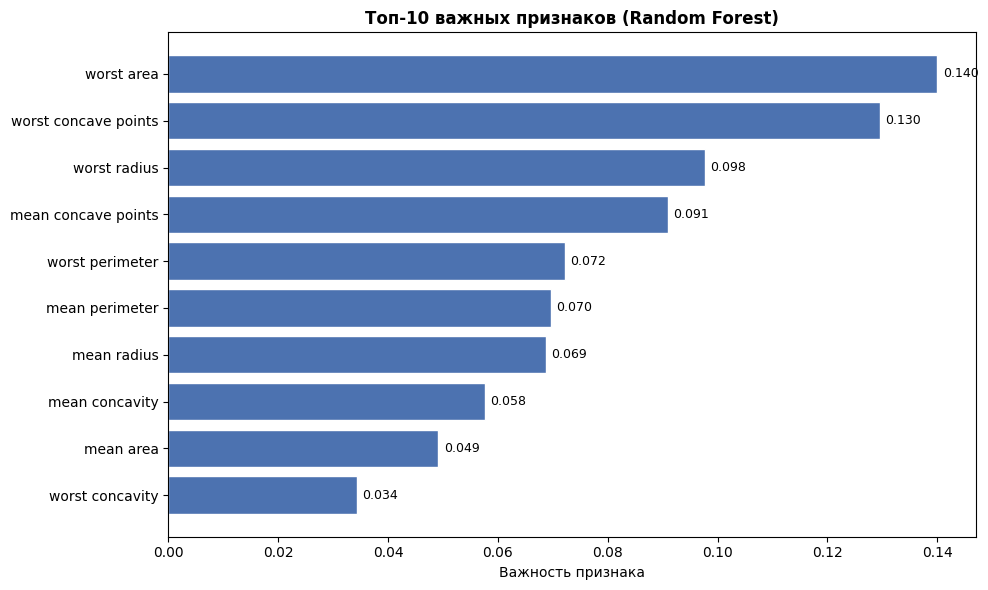


Чем выше значение, тем сильнее этот признак влияет на предсказание модели.


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=True).tail(10)

bars = ax.barh(top10.index, top10.values, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Важность признака')
ax.set_title('Топ-10 важных признаков (Random Forest)', fontweight='bold')

for bar, val in zip(bars, top10.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nЧем выше значение, тем сильнее этот признак влияет на предсказание модели.")
